## **최종 데이터**

### **1. 음식점 데이터와 미용업 데이터 결합**

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df_food = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/00_0음식점 최종 수정완료.csv")
df_salon = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/00_광진구 미용업 점수 최종.csv")

In [22]:
df_food.head()  # '동'열 삭제해야 함 

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수,총 점수,지역화폐
0,가쯔동,8000,코코도리,일식,화양동,14018.67,30.053272,-30.0,0.053272,O
1,규동,8000,코코도리,일식,화양동,14018.67,30.053272,-30.0,0.053272,O
2,우동,6000,건대우동집,"돈까스,우동",화양동,10659.55,30.598712,-30.0,0.598712,O
3,아메리카노,2500,테이큰커피,카페,화양동,4487.85,31.005827,-30.0,1.005827,O
4,아메리카노,2500,테이큰커피,카페,화양동,4487.85,31.005827,-30.0,1.005827,O


In [23]:
df_food[df_food['주메뉴']=='카페']

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수,총 점수,지역화폐
3,아메리카노,2500,테이큰커피,카페,화양동,4487.85,31.005827,-30.0,1.005827,O
4,아메리카노,2500,테이큰커피,카페,화양동,4487.85,31.005827,-30.0,1.005827,O
5,아메리카노,2500,자양다방,카페,자양동,4487.85,31.005827,-30.0,1.005827,O
6,아메리카노(hot),2500,주민커피,카페,자양동,4487.85,31.005827,-30.0,1.005827,O
7,카페라떼(HOT),2500,자양다방,카페,자양동,4487.85,31.005827,-30.0,1.005827,O
...,...,...,...,...,...,...,...,...,...,...
876,아메리카노(HOT),1500,빽다방 신자초사거리점,카페,자양동,4487.85,46.603496,8.0,54.603496,O
877,아메리카노,1500,와플그란데,카페,군자동,4487.85,46.603496,8.0,54.603496,O
878,브루커피,1500,레이지눅,카페,중곡동,4487.85,46.603496,8.0,54.603496,O
898,아메리카노 (ICED),2000,빽다방 군자역점,카페,군자동,4487.85,38.804661,20.0,58.804661,O


In [24]:
df_salon.head() # '메뉴 타입' 열 이름 '주메뉴'로 바꾸기 

,메뉴,가격,가게명,메뉴 타입,평균가격,가격점수,위생점수,총 점수,지역화폐
0,첫방문 커트,17500,헤어더뷰 건대점,커트,22527.22,22.316202,0,22.316202,O
1,학생 컷,17000,박준뷰티랩 뚝섬유원지역점,커트,22527.22,24.535739,0,24.535739,O
2,여성 컷,22400,제오헤어 강변역점,커트,22527.22,0.564739,0,0.564739,O
3,여성 커트(직급별 차등 요금),22000,헤어웨이 광장점,커트,22527.22,2.340369,0,2.340369,O
4,(신규)디자인컷-남성,16500,에이컨셉 구의점,커트,22527.22,26.755277,0,26.755277,O


In [25]:
df_food.drop(columns='동', inplace=True)
df_salon.rename(columns={'메뉴 타입':'주메뉴'}, inplace=True)

df_food['업종'] = '요식업'
df_salon['업종'] = '미용업'

df_salon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   메뉴      57 non-null     object 
 1   가격      57 non-null     int64  
 2   가게명     57 non-null     object 
 3   주메뉴     57 non-null     object 
 4   평균가격    57 non-null     float64
 5   가격점수    57 non-null     float64
 6   위생점수    57 non-null     int64  
 7   총 점수    57 non-null     float64
 8   지역화폐    57 non-null     object 
 9   업종      57 non-null     object 
dtypes: float64(3), int64(2), object(5)
memory usage: 4.6+ KB


In [26]:
# 미용실 데이터 중복값 처리

numeric_cols = df_salon.select_dtypes(include='number').columns.tolist()
non_numeric_cols = [col for col in df_salon.columns if col not in numeric_cols and col != '가게명']

df_salon = df_salon.groupby('가게명', as_index=False).agg(
    {**{col: 'mean' for col in numeric_cols},
     **{col: 'first' for col in non_numeric_cols}}
)

df_salon.head()

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종
0,HU헤어,22000.0,22527.220,2.340369,0.0,2.340369,남성컷,커트,O,미용업
1,디핑고헤어,33000.0,39706.715,12.205252,0.0,12.205252,남성커트,커트,O,미용업
2,리안헤어 강변역점,22000.0,22527.220,3.389721,0.0,3.389721,남성컷,커트,O,미용업
3,리안헤어 구의역점,22000.0,22527.220,3.389721,0.0,3.389721,남성컷,커트,O,미용업
4,박준뷰티랩 뚝섬유원지역점,18000.0,22527.220,20.096665,0.0,20.096665,학생 컷,커트,O,미용업


In [34]:
duplicate_names = df_salon[df_salon['가게명'].duplicated()]
has_duplicates = df_salon['가게명'].duplicated().any()

print("중복 여부:", has_duplicates)
print("중복된 가게명들:")
print(duplicate_names)

중복 여부: False
중복된 가게명들:
Empty DataFrame
Columns: [가게명, 가격, 평균가격, 가격점수, 위생점수, 총 점수, 메뉴, 주메뉴, 지역화폐, 업종]
Index: []


In [37]:
numeric_cols = df_food.select_dtypes(include='number').columns.tolist()
non_numeric_cols = [col for col in df_food.columns if col not in numeric_cols and col != '가게명']

df_food = df_food.groupby('가게명', as_index=False).agg(
    {**{col: 'mean' for col in numeric_cols},
     **{col: 'first' for col in non_numeric_cols}}
)

df_food.head()

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종
0,1983김지영,8000.0,14931.95,32.496526,8.0,40.496526,돈까스토핑김치볶음밥,한식,O,요식업
1,206숯불구이,15000.0,20441.05,18.632776,8.0,26.632776,소살치살(150g),"육류,고기",O,요식업
2,550커피,3250.0,4487.85,19.307575,8.0,27.307575,카페라떼,카페,O,요식업
3,가네초밥,15000.0,17142.11,8.747330,8.0,16.747330,새우튀김,"초밥,롤",O,요식업
4,가람성,4500.0,8158.91,31.391902,-30.0,1.391902,짜장면,중식,O,요식업


In [35]:
df_food.head()

,메뉴,가격,가게명,주메뉴,평균가격,가격점수,위생점수,총 점수,지역화폐,업종
0,가쯔동,8000,코코도리,일식,14018.67,30.053272,-30.0,0.053272,O,요식업
1,규동,8000,코코도리,일식,14018.67,30.053272,-30.0,0.053272,O,요식업
2,우동,6000,건대우동집,"돈까스,우동",10659.55,30.598712,-30.0,0.598712,O,요식업
3,아메리카노,2500,테이큰커피,카페,4487.85,31.005827,-30.0,1.005827,O,요식업
4,아메리카노,2500,테이큰커피,카페,4487.85,31.005827,-30.0,1.005827,O,요식업


In [38]:
duplicate_names = df_food[df_food['가게명'].duplicated()]
has_duplicates = df_food['가게명'].duplicated().any()

print("중복 여부:", has_duplicates)
print("중복된 가게명들:")
print(duplicate_names)

중복 여부: False
중복된 가게명들:
Empty DataFrame
Columns: [가게명, 가격, 평균가격, 가격점수, 위생점수, 총 점수, 메뉴, 주메뉴, 지역화폐, 업종]
Index: []


In [39]:
df_all = pd.concat([df_food, df_salon], ignore_index = True)
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   가게명     575 non-null    object 
 1   가격      575 non-null    float64
 2   평균가격    575 non-null    float64
 3   가격점수    575 non-null    float64
 4   위생점수    575 non-null    float64
 5   총 점수    575 non-null    float64
 6   메뉴      575 non-null    object 
 7   주메뉴     575 non-null    object 
 8   지역화폐    575 non-null    object 
 9   업종      575 non-null    object 
dtypes: float64(5), object(5)
memory usage: 45.1+ KB


In [40]:
df_all.sort_values(by='총 점수', ascending=False).head()

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종
292,심마니유황오리,11500.0,41750.00,50.718563,30.0,80.718563,윙 오리탕,오리,O,요식업
486,태평양수산회세꼬시,14000.0,33927.84,41.115167,30.0,71.115167,생선초밥,회,O,요식업
273,스시키요이,2000.0,17142.11,61.832977,8.0,69.832977,계란 (2pcs),"초밥,롤",O,요식업
270,스시노칸도 어린이대공원역점,2200.0,17142.11,61.016275,8.0,69.016275,초밥한접시,"초밥,롤",O,요식업
272,스시오리,2600.0,17142.11,59.382871,8.0,67.382871,광어지느러미초밥(1ps),"초밥,롤",O,요식업


In [41]:
df = df_all.sort_values(by='총 점수', ascending=False)
df.to_csv('00_0_최종 점수 데이터.csv', index=False, encoding='utf-8-sig')

### **2. 시각화**

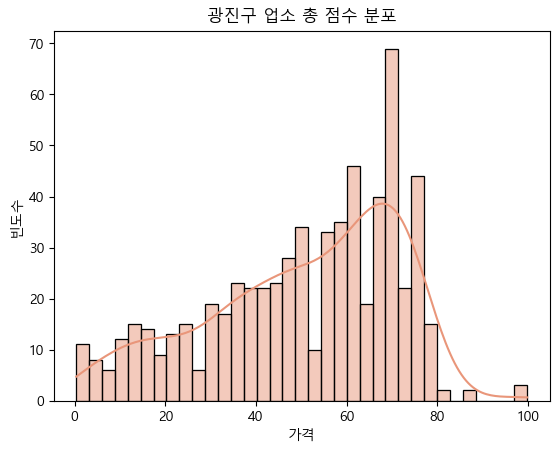

In [12]:
sns.histplot(data= df, 
             x='총 점수', bins=35, kde=True, color='darksalmon')
plt.title('광진구 업소 총 점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

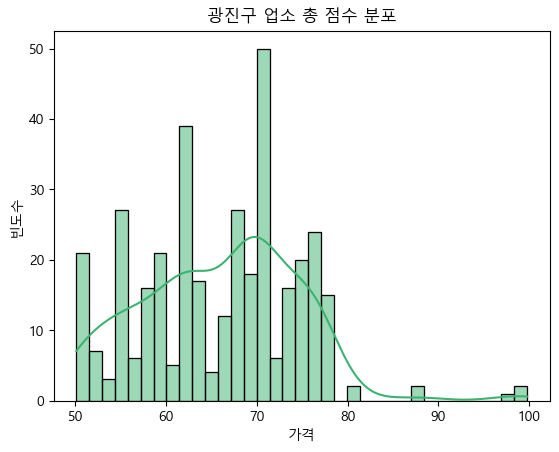

In [14]:
sns.histplot(data= df[df['총 점수']>=50], 
             x='총 점수', bins=35, kde=True, color='mediumseagreen')
plt.title('광진구 업소 총 점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [15]:
df[df['총 점수']>=50]

,가게명,지역화폐,메뉴,가격,주메뉴,평균가격,가격점수,위생점수,총 점수,업종
605,명가순대국,O,순대국,9000.0,분식,9028.96,69.775478,30.0,99.775478,요식업
604,천미향,O,유니자장면,8000.0,중식,8158.91,68.636619,30.0,98.636619,요식업
603,양평해장국,O,양선지해장국,11000.0,기본탕류,11351.06,67.835074,30.0,97.835074,요식업
602,능동국시,O,능동국시,7000.0,국수,8406.47,58.288437,30.0,88.288437,요식업
601,빽다방 구의중앙점,O,아이스티 망고 추가(아망추)w노란빨대,4300.0,카페,4487.85,67.069978,20.0,87.069978,요식업
...,...,...,...,...,...,...,...,...,...,...
251,양숙이네,O,김치찌개,9000.0,한식,14931.95,42.191408,8.0,50.191408,요식업
249,이든한끼,O,제육볶음,9000.0,한식,14931.95,42.191408,8.0,50.191408,요식업
252,어테이블,O,된장찌개,9000.0,한식,14931.95,42.191408,8.0,50.191408,요식업
250,왕소구이,O,고등어구이,9000.0,한식,14931.95,42.191408,8.0,50.191408,요식업


### **3. 기존 착한가격업소와의 비교**

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575 entries, 292 to 475
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   가게명     575 non-null    object 
 1   가격      575 non-null    float64
 2   평균가격    575 non-null    float64
 3   가격점수    575 non-null    float64
 4   위생점수    575 non-null    float64
 5   총 점수    575 non-null    float64
 6   메뉴      575 non-null    object 
 7   주메뉴     575 non-null    object 
 8   지역화폐    575 non-null    object 
 9   업종      575 non-null    object 
dtypes: float64(5), object(5)
memory usage: 49.4+ KB


In [43]:
df_top50 = df.sort_values(by='총 점수', ascending=False)
df_top50.head()

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종
292,심마니유황오리,11500.0,41750.00,50.718563,30.0,80.718563,윙 오리탕,오리,O,요식업
486,태평양수산회세꼬시,14000.0,33927.84,41.115167,30.0,71.115167,생선초밥,회,O,요식업
273,스시키요이,2000.0,17142.11,61.832977,8.0,69.832977,계란 (2pcs),"초밥,롤",O,요식업
270,스시노칸도 어린이대공원역점,2200.0,17142.11,61.016275,8.0,69.016275,초밥한접시,"초밥,롤",O,요식업
272,스시오리,2600.0,17142.11,59.382871,8.0,67.382871,광어지느러미초밥(1ps),"초밥,롤",O,요식업


In [44]:
df_top50.to_csv('00_0총점수 상위 50개.csv', index=False, encoding='utf-8-sig')

In [49]:
df_pri = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/크롤링 데이터.csv")
df_pri.head()

,가게명,주메뉴,동,상세주소,평점,메뉴목록
0,백일도,회,중곡동,서울 광진구 능동로47길 37,4.0,"광어&연어(30,000원), 광어&우럭&연어(40,000원), 전복(15,000원)..."
1,도톰 본점,"육류,고기",중곡동,서울 광진구 능동로 386 1층,4.8,"도톰삼겹살 (180g)(16,000원), 도톰목살 (180g)(16,000원), 가..."
2,포차조개구이,조개,중곡동,서울 광진구 용마산로 40 1층,4.5,"모듬 조개찜 (소)(55,000원), 모듬 조개구이 (중)(55,000원), 모듬 ..."
3,택이네조개전골 군자역점,조개,중곡동,서울 광진구 천호대로 591 유신빌딩 1층,3.4,"조개전골 (2인)(49,000원), 조개 칼국수(11,000원), 조개 전복칼국수(..."
4,장군갈비,갈비,중곡동,서울 광진구 용마산로 11,3.6,"생갈비 (1인분)(65,000원), 양념갈비 (1인분)(54,000원), 생꽃등심 ..."


In [51]:
df_top50 = df_top50.merge(
    df_pri[['가게명', '상세주소']], 
    on='가게명', 
    how='left'
)

df_top50.head()

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종,상세주소
0,심마니유황오리,11500.0,41750.00,50.718563,30.0,80.718563,윙 오리탕,오리,O,요식업,서울 광진구 긴고랑로 85
1,태평양수산회세꼬시,14000.0,33927.84,41.115167,30.0,71.115167,생선초밥,회,O,요식업,"서울 광진구 군자로 183 1,2층"
2,스시키요이,2000.0,17142.11,61.832977,8.0,69.832977,계란 (2pcs),"초밥,롤",O,요식업,서울 광진구 자양로 46 1층 102호
3,스시노칸도 어린이대공원역점,2200.0,17142.11,61.016275,8.0,69.016275,초밥한접시,"초밥,롤",O,요식업,서울 광진구 광나루로 369 광진두산위브파크 2층 201호
4,스시오리,2600.0,17142.11,59.382871,8.0,67.382871,광어지느러미초밥(1ps),"초밥,롤",O,요식업,서울 광진구 천호대로132길 56 1층


In [52]:
df_top50.to_csv('최종 수정 데이터.csv', index=False, encoding='utf-8-sig')

In [54]:

df = df_top50.drop(columns='상세주소')

df_yes = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/98_광진구 착한업소 가격.csv", encoding='cp949')
df_yes.drop(columns='Unnamed: 0', inplace=True)
df_yes.head()

,메뉴,가격,업소명,시도,시군,업종,주소
0,삼겹살,15000.0,금강숯불생고기,서울특별시,광진구,한식,서울특별시 광진구 용마산로7길 9(중곡동)
1,김치찌개,7000.0,흥부농장,서울특별시,광진구,한식,서울특별시 광진구 뚝섬로59길 81-2(자양동)
2,미용료(파마),35000.0,머리천국미용실,서울특별시,광진구,미용업,서울특별시 광진구 뚝섬로49길 31(자양동)
3,미용료(파마),30000.0,모짜르트헤어샵,서울특별시,광진구,미용업,서울특별시 광진구 자양번영로1길 12(자양동)
4,미용료(파마),40000.0,유나미용실,서울특별시,광진구,미용업,서울특별시 광진구 동일로4길 44(자양동)


In [60]:
duplicate_names = df_top50[df_top50['가게명'].duplicated()]
has_duplicates = df_top50['가게명'].duplicated().any()

print("중복 여부:", has_duplicates)
print("중복된 가게명들:")
print(duplicate_names)

중복 여부: True
중복된 가게명들:
         가게명       가격      평균가격       가격점수  위생점수       총 점수  \
19       어울림   7500.0  25275.83  49.229169   8.0  57.229169   
33      고향맛집   5500.0  14931.95  44.216362   8.0  52.216362   
61      만나식당   6500.0  14931.95  39.528427   8.0  47.528427   
70     수내닭꼬치   8500.0  18920.29  38.552279   8.0  46.552279   
75      전주밥상   7000.0  14931.95  37.184460   8.0  45.184460   
100      육일관  15500.0  20441.05  16.920535  25.0  41.920535   
206   백남옥손만두   6000.0   9028.96  23.483015   8.0  31.483015   
227    명가순대국   9000.0   9028.96   0.224522  30.0  30.224522   
229      고깃집  14000.0  20441.05  22.057257   8.0  30.057257   
234  전주콩나물국밥   7125.0  10344.93  21.787977   8.0  29.787977   
250      옛날집   8000.0  11351.06  20.665400   8.0  28.665400   
251      옛날집   8000.0  11351.06  20.665400   8.0  28.665400   
328   솥뚜껑삼겹살  12000.0  15371.95  15.355014   8.0  23.355014   
483      모두랑   3250.0   9028.96  44.803300 -30.0  14.803300   
501    이모네김밥   3500.0   9028.96  

In [55]:
df_yes.rename(columns={'업소명':'가게명'}, inplace=True)

df['가게명'].isin(df_yes['가게명']).any()

True

In [56]:
common_names = set(df['가게명']) & set(df_yes['가게명'])
print(common_names)

{'구름초밥', '중국관', '달디빈', '금강숯불생고기', '오목대', '옛골', '마미가', '석기시대짜장마을', '곰곰탕', '종로식당', '송영옥진주육전냉면', '마니아우동', '새맛식당', '자양다방'}


In [57]:
df_yes['착한가격업소'] = 'O'
df = df.merge(
    df_yes[['가게명', '착한가격업소']], 
    on='가게명', 
    how='left'
)

df.head()

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종,착한가격업소
0,심마니유황오리,11500.0,41750.00,50.718563,30.0,80.718563,윙 오리탕,오리,O,요식업,NaN
1,태평양수산회세꼬시,14000.0,33927.84,41.115167,30.0,71.115167,생선초밥,회,O,요식업,NaN
2,스시키요이,2000.0,17142.11,61.832977,8.0,69.832977,계란 (2pcs),"초밥,롤",O,요식업,NaN
3,스시노칸도 어린이대공원역점,2200.0,17142.11,61.016275,8.0,69.016275,초밥한접시,"초밥,롤",O,요식업,NaN
4,스시오리,2600.0,17142.11,59.382871,8.0,67.382871,광어지느러미초밥(1ps),"초밥,롤",O,요식업,NaN


In [58]:
df[df['착한가격업소']=='O']

,가게명,가격,평균가격,가격점수,위생점수,총 점수,메뉴,주메뉴,지역화폐,업종,착한가격업소
59,옛골,6500.0,14931.95,39.528427,8.0,47.528427,제육볶음,한식,O,요식업,O
76,종로식당,7000.0,14931.95,37.184460,8.0,45.184460,김치찌개,한식,O,요식업,O
77,종로식당,7000.0,14931.95,37.184460,8.0,45.184460,김치찌개,한식,O,요식업,O
79,마니아우동,5000.0,10659.55,37.165593,8.0,45.165593,짜장,"돈까스,우동",O,요식업,O
80,마니아우동,5000.0,10659.55,37.165593,8.0,45.165593,짜장,"돈까스,우동",O,요식업,O
106,석기시대짜장마을,4250.0,8158.91,33.536796,8.0,41.536796,간짜장,중식,O,요식업,O
107,석기시대짜장마을,4250.0,8158.91,33.536796,8.0,41.536796,간짜장,중식,O,요식업,O
143,구름초밥,9750.0,17142.11,30.185765,8.0,38.185765,모듬초밥,"초밥,롤",O,요식업,O
203,마미가,7000.0,10659.55,24.031831,8.0,32.031831,돈가스,"돈까스,우동",O,요식업,O
204,마미가,7000.0,10659.55,24.031831,8.0,32.031831,돈가스,"돈까스,우동",O,요식업,O
